### SadA Docking replication

Ran 3 replicates of SadA docking for a double mutant `X42A.X100D` with ${10}^4$ structures for the docking part. 

`Misc Notes`
* The first two replications took greater than 12 hours on the group server using 1 CPU. 
* The third replication has `qsar:grid_dir` option enabled to save grid scores. 
  - It ran in ~14 hours (no appreciable difference from the other two replications)

In [1]:
import pathlib

import numpy as np
import pandas as pd
import scipy as sp

import matplotlib.pyplot as plt
import seaborn as sns

import rosetta_db

from plot_utils import annotate_ax_with_correlations

In [2]:
replicates = [1,2,3]
rep_df_list = []

for r in replicates:
    rdir = pathlib.Path(rosetta_db.ROSETTA_SCRATCH_DIR) \
                /  f"misc/working_rep{r}"
    rdf = pd.read_csv(rdir / "Relax_commandline/score.sc", 
                delim_whitespace=True, skiprows=1)
    rdf["rep"] = r
    rep_df_list.append(rdf)

rep_df = pd.concat(rep_df_list)
del rep_df_list
len(rep_df)

30000

In [3]:
rep_df.head()

,SCORE:,total_score,Grid_score,Transform_accept_ratio,angle_constraint,atom_pair_constraint,chainbreak,classic_grid_X,coordinate_constraint,dihedral_constraint,...,if_X_ref,interface_delta_X,ligand_is_touching_X,omega,p_aa_pp,pro_close,ref,total_score_X,description,rep
0,SCORE:,-874.241,-30.0,0.720,0.0,0.0,0.0,-27.0,0.439,0.0,...,0.0,-8.770,1.0,48.759,-40.902,1.137,-42.57,-27.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_00001,1
1,SCORE:,-872.679,-29.0,0.744,0.0,0.0,0.0,-25.0,0.821,0.0,...,0.0,-3.342,1.0,48.791,-40.936,1.140,-42.57,-25.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_00002,1
2,SCORE:,-872.750,-29.0,0.776,0.0,0.0,0.0,-30.0,0.620,0.0,...,0.0,-2.696,1.0,48.804,-41.230,1.128,-42.57,-30.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_00003,1
3,SCORE:,-872.887,-28.0,0.720,0.0,0.0,0.0,-24.0,1.038,0.0,...,0.0,-6.661,1.0,49.470,-40.805,1.137,-42.57,-24.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_00004,1
4,SCORE:,-873.310,-29.0,0.716,0.0,0.0,0.0,-24.0,0.346,0.0,...,0.0,-7.939,1.0,49.018,-41.106,1.184,-42.57,-24.0,SadA_NSLeu_Corrected_3701_0002_0001_0001_00005,1


In [4]:
rep_df.columns

Index(['SCORE:', 'total_score', 'Grid_score', 'Transform_accept_ratio',
       'angle_constraint', 'atom_pair_constraint', 'chainbreak',
       'classic_grid_X', 'coordinate_constraint', 'dihedral_constraint',
       'dslf_ca_dih', 'dslf_cs_ang', 'dslf_ss_dih', 'dslf_ss_dst', 'fa_atr',
       'fa_dun', 'fa_elec', 'fa_pair', 'fa_rep', 'fa_sol', 'hbond_bb_sc',
       'hbond_lr_bb', 'hbond_sc', 'hbond_sr_bb', 'if_X_angle_constraint',
       'if_X_atom_pair_constraint', 'if_X_chainbreak',
       'if_X_coordinate_constraint', 'if_X_dihedral_constraint',
       'if_X_dslf_ca_dih', 'if_X_dslf_cs_ang', 'if_X_dslf_ss_dih',
       'if_X_dslf_ss_dst', 'if_X_fa_atr', 'if_X_fa_dun', 'if_X_fa_elec',
       'if_X_fa_pair', 'if_X_fa_rep', 'if_X_fa_sol', 'if_X_hbond_bb_sc',
       'if_X_hbond_lr_bb', 'if_X_hbond_sc', 'if_X_hbond_sr_bb', 'if_X_omega',
       'if_X_p_aa_pp', 'if_X_pro_close', 'if_X_ref', 'interface_delta_X',
       'ligand_is_touching_X', 'omega', 'p_aa_pp', 'pro_close', 'ref',
       't

### Correlations between `interface_delta_X` and `total_score` within replicates

The first set of plots is the entire dataset. The next two sets of plots are for the first 1000 structures and the first 100 structures respectively. 

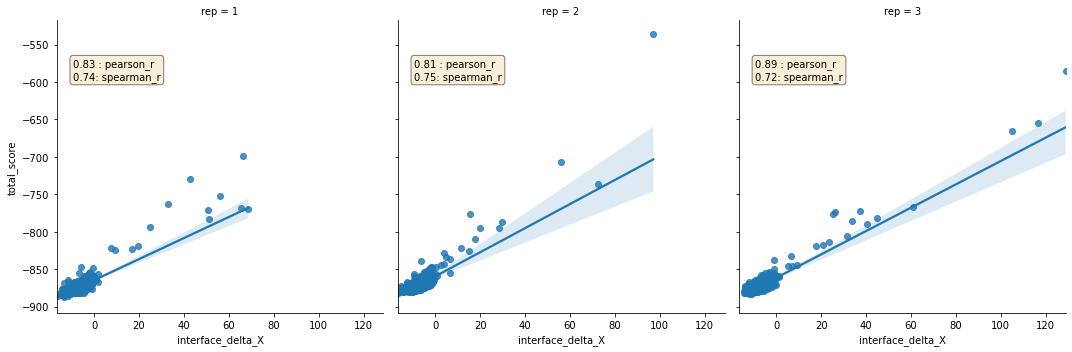

In [5]:
g = sns.lmplot(x="interface_delta_X", y="total_score", data=rep_df, col="rep")
g.map(annotate_ax_with_correlations, "interface_delta_X", "total_score")

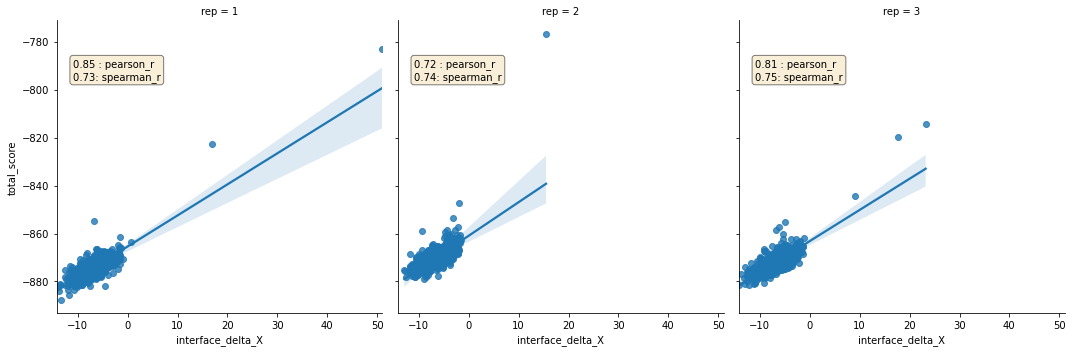

In [6]:
g = sns.lmplot(x="interface_delta_X", y="total_score", data=rep_df.groupby("rep").head(1000), col="rep")
g.map(annotate_ax_with_correlations, "interface_delta_X", "total_score")

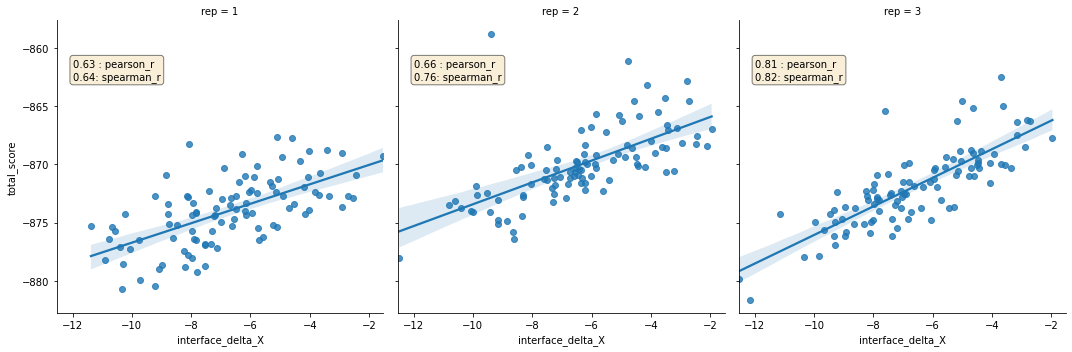

In [7]:
g = sns.lmplot(x="interface_delta_X", y="total_score", data=rep_df.groupby("rep").head(100), col="rep")
g.map(annotate_ax_with_correlations, "interface_delta_X", "total_score")

### Correlations between `interface_delta_X` and `total_score` across replicates

Here we look at the minimum score after taking random samples of 100 structures each

In [8]:
import numpy as np
np.random.seed(111)

In [27]:
split_dfs = rep_df.groupby("rep")
#split_df_list = [split_dfs.get_group(1) for r in replicates]

In [54]:
def get_minimum_total_score(df, num_structs):
    # select num_structs (say 100) and find the minimum total score
    selected_structs = np.random.choice(df.index, num_structs)
    return df.total_score.iloc[selected_structs].min()

def get_minimum_interface_score(df, num_structs):
    # select num_structs (say 100) and find the minimum total score
    # then find the interface delta score corresponding to that minimum total score
    selected_structs = np.random.choice(df.index, num_structs)
    return df.interface_delta_X[df.total_score.iloc[selected_structs].idxmin()]

def get_mimimum_as_array(df, func, num_mins, **kwargs):
    """Call one of the minimum functions num_mins times and save output in an array"""
    return np.array([func(df=df, **kwargs) for _ in range(num_mins)])

In [57]:
min_interface_scores_1 = get_mimimum_as_array(
    df=split_dfs.get_group(1), func=get_minimum_interface_score, 
    num_mins=500, num_structs=100) 
min_interface_scores_2 = get_mimimum_as_array(
    df=split_dfs.get_group(2), func=get_minimum_interface_score, 
    num_mins=500, num_structs=100) 
min_interface_scores_3 = get_mimimum_as_array(
    df=split_dfs.get_group(3), func=get_minimum_interface_score, 
    num_mins=500, num_structs=100) 

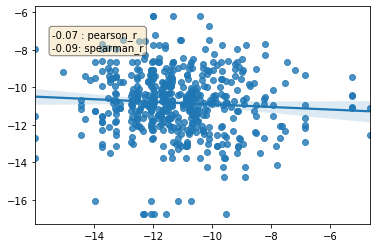

In [64]:
sns.regplot(x=min_interface_scores_1, y=min_interface_scores_2)
annotate_ax_with_correlations(x=min_interface_scores_1, y=min_interface_scores_2)

In [66]:
min_total_scores_1 = get_mimimum_as_array(
    df=split_dfs.get_group(1), func=get_minimum_total_score, 
    num_mins=500, num_structs=100) 
min_total_scores_2 = get_mimimum_as_array(
    df=split_dfs.get_group(2), func=get_minimum_total_score, 
    num_mins=500, num_structs=100) 
min_total_scores_3 = get_mimimum_as_array(
    df=split_dfs.get_group(3), func=get_minimum_total_score, 
    num_mins=500, num_structs=100) 

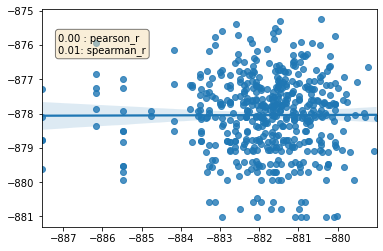

In [67]:
sns.regplot(x=min_total_scores_1, y=min_total_scores_2)
annotate_ax_with_correlations(x=min_total_scores_1, y=min_total_scores_2)